## This notebook is meant to help the learner practise and reinforce all they have learnt about data visualisation in Python

In [4]:
!pip install matplotlib
!pip install seaborn

     ------------------------------------ 293.3/293.3 kB 421.8 kB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
soccer_df = pd.read_csv("https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/fundamentals/football_players.csv",low_memory=False)
soccer_df

,Name,Age,Nationality,Overall,Acceleration,Aggression,Agility,Balance,Ball control,Composure,...,Short passing,Shot power,Sliding tackle,Sprint speed,Stamina,Standing tackle,Strength,Vision,Volleys,Preferred Positions
0,Cristiano Ronaldo,32,Portugal,94,89,63,89,63,93,95,...,83,94,23,91,92,31,80,85,88,ST LW
1,L. Messi,30,Argentina,93,92,48,90,95,95,96,...,88,85,26,87,73,28,59,90,85,RW
2,Neymar,25,Brazil,92,94,56,96,82,95,92,...,81,80,33,90,78,24,53,80,83,LW
3,L. Suárez,30,Uruguay,92,88,78,86,60,91,83,...,83,87,38,77,89,45,80,84,88,ST
4,M. Neuer,31,Germany,92,58,29,52,35,48,70,...,55,25,11,61,44,10,83,70,11,GK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17976,A. Kelsey,17,England,46,24,16,38,26,12,23,...,19,19,10,32,28,11,50,26,6,GK
17977,B. Richardson,47,England,46,25,44,35,44,22,44,...,12,13,13,25,32,12,47,17,12,GK
17978,J. Young,17,Scotland,46,66,26,60,77,41,50,...,42,42,14,51,33,17,32,37,33,ST
17979,J. Lundstram,18,England,46,57,46,58,74,43,45,...,49,43,47,58,49,48,46,51,25,CM


In [8]:
cols = ['Age', 'Overall', 'Acceleration', 'Aggression',
       'Agility', 'Balance', 'Ball control', 'Composure', 'Crossing', 'Curve',
       'Dribbling', 'Finishing', 'Free kick accuracy', 'GK diving',
       'GK handling', 'GK kicking', 'GK positioning', 'GK reflexes',
       'Heading accuracy', 'Interceptions', 'Jumping', 'Long passing',
       'Long shots', 'Marking', 'Penalties', 'Positioning', 'Reactions',
       'Short passing', 'Shot power', 'Sliding tackle', 'Sprint speed',
       'Stamina', 'Standing tackle', 'Strength', 'Vision', 'Volleys']

soccer_df[cols] = soccer_df[cols].apply(pd.to_numeric, errors='coerce', axis=1)

#### Exercise 1: Comparing the overall ratings of players across the top five nationalities (based on the no. of players in each nationality)

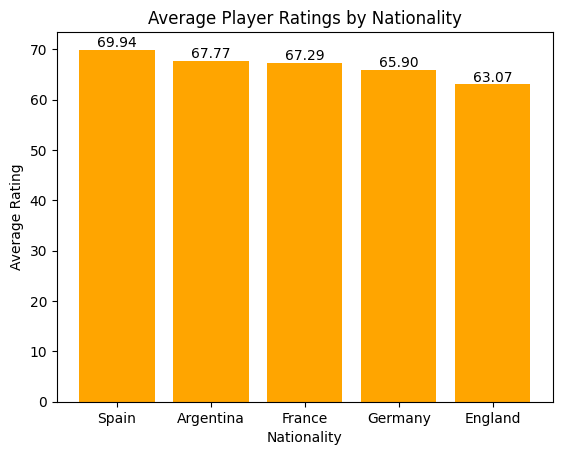

In [99]:
counts = soccer_df.groupby('Nationality').size()

top5_nationalities = counts.sort_values(ascending=False).head(5)
# print(top5_nationalities)

top5 = top5_nationalities.index
# print(top5)

filtered_df = soccer_df[soccer_df['Nationality'].isin(top5)]
# print(filtered_df)

result = filtered_df.groupby('Nationality')['Overall'].mean().sort_values(ascending=False)
# print(result)
# print(result.loc[top5])

bars = plt.bar(result.index, result.values, color='orange')

plt.title('Average Player Ratings by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Average Rating')

plt.bar_label(bars, fmt='%.2f')
plt.show()

#### Exercise 2: Generating a Pie chart to visualize the percentage distribution of player ages

In [100]:
soccer_df.head()

,Name,Age,Nationality,Overall,Acceleration,Aggression,Agility,Balance,Ball control,Composure,...,Short passing,Shot power,Sliding tackle,Sprint speed,Stamina,Standing tackle,Strength,Vision,Volleys,Preferred Positions
0,Cristiano Ronaldo,32.0,Portugal,94.0,89.0,63.0,89.0,63.0,93.0,95.0,...,83.0,94.0,23.0,91.0,92.0,31.0,80.0,85.0,88.0,ST LW
1,L. Messi,30.0,Argentina,93.0,92.0,48.0,90.0,95.0,95.0,96.0,...,88.0,85.0,26.0,87.0,73.0,28.0,59.0,90.0,85.0,RW
2,Neymar,25.0,Brazil,92.0,94.0,56.0,96.0,82.0,95.0,92.0,...,81.0,80.0,33.0,90.0,78.0,24.0,53.0,80.0,83.0,LW
3,L. Suárez,30.0,Uruguay,92.0,88.0,78.0,86.0,60.0,91.0,83.0,...,83.0,87.0,38.0,77.0,89.0,45.0,80.0,84.0,88.0,ST
4,M. Neuer,31.0,Germany,92.0,58.0,29.0,52.0,35.0,48.0,70.0,...,55.0,25.0,11.0,61.0,44.0,10.0,83.0,70.0,11.0,GK


<class 'pandas.core.series.Series'>
15-19    3257
20-24    6860
25-29    5330
30-34    2257
35+       277
Name: Age, dtype: int64


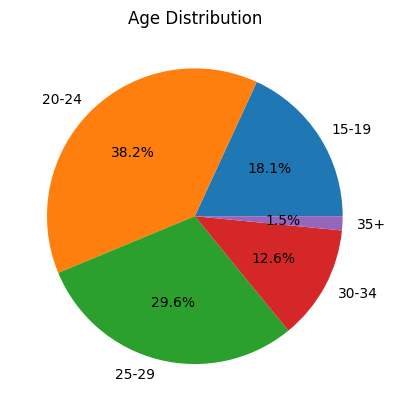

In [147]:
player_ages = soccer_df['Age']
print(type(player_ages))

bins = [15, 20, 25, 30, 35, np.inf]
labels = ['15-19', '20-24', '25-29', '30-34', '35+']
grouped_ages = pd.cut(player_ages, bins=bins, labels=labels)

age_distribution = grouped_ages.value_counts().sort_index()
print(age_distribution)

# Plot the pie chart
plt.pie(
    age_distribution,
    labels=age_distribution.index,
    autopct='%1.1f%%'
)

plt.title("Age Distribution")
# plt.ylabel('')
plt.show()

#### Exercise 3: Drawing a Line graph to show the trend of average Acceleration and Sprint speed across different age groups

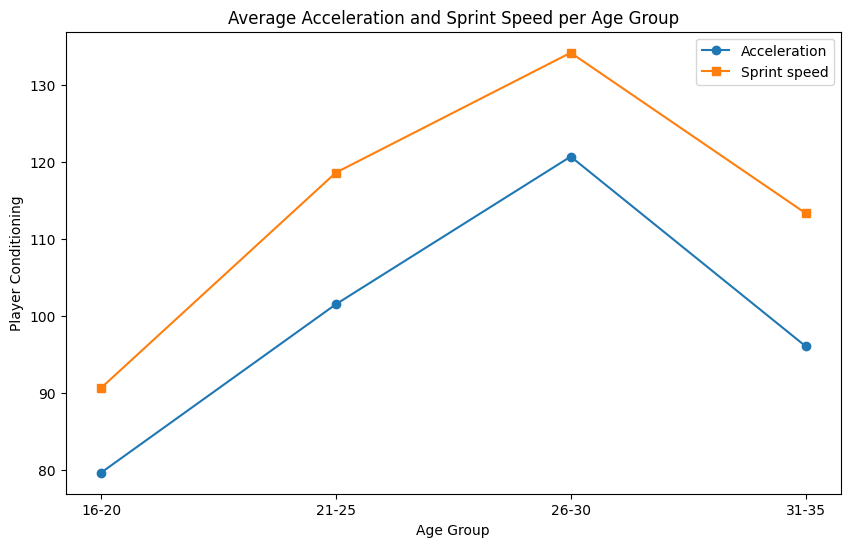

In [123]:
age_bins = [15, 20, 25, 30, 35]

labels = ['16-20', '21-25', '26-30', '31-35']

soccer_df['Age Group'] = pd.cut(
    soccer_df['Age'],
    bins=age_bins,
    labels=labels
)

grouped_df = soccer_df.groupby('Age Group')[['Acceleration', 'Sprint speed']].mean()

# print(grouped_df)
# print(soccer_df.head(1))

plt.figure(figsize=(10, 6))

plt.plot(
    grouped_df.index,
    grouped_df['Acceleration'],
    marker='o',
    label='Acceleration'
)

plt.plot(
    grouped_df.index,
    grouped_df['Sprint speed'],
    marker='s',
    label='Sprint speed'
)

plt.title('Average Acceleration and Sprint Speed per Age Group')
plt.xlabel('Age Group')
plt.ylabel('Player Conditioning')
plt.legend()

plt.show()

#### Exercise 4: Picking players from the top three nationalities based on the average Overall rating and then creating a box plot of various skills

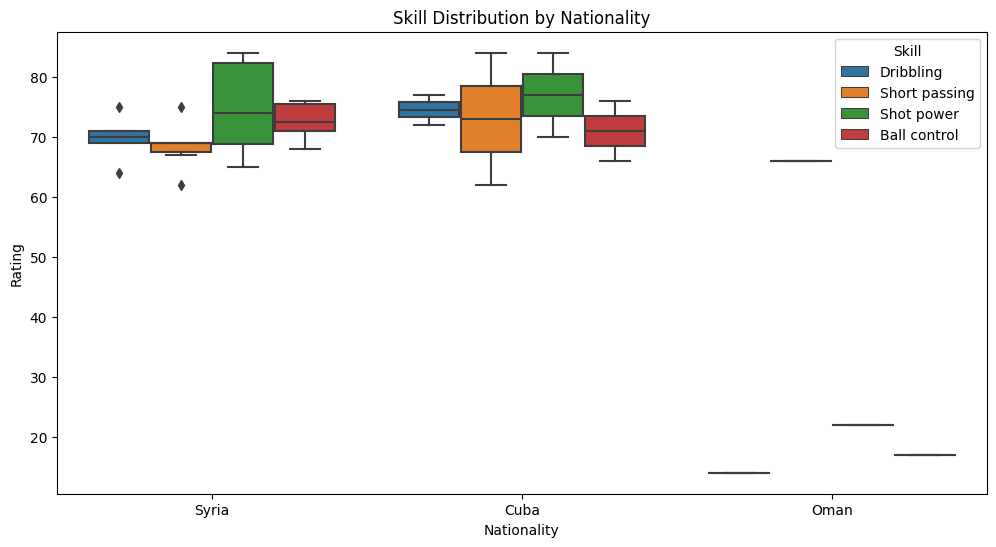

In [138]:
grouped_soccer_df = soccer_df.groupby('Nationality')['Overall'].mean().sort_values(ascending=False).head(3)

# print(grouped_soccer_df)

filtered_soccer_df = soccer_df[soccer_df['Nationality'].isin(grouped_soccer_df.index)]

# print(filtered_soccer_df)

plot_df = pd.melt(
    filtered_soccer_df,
    id_vars='Nationality',
    value_vars=[
        'Dribbling', 'Short passing',
        'Shot power', 'Ball control'
    ],
    var_name='Skill',
    value_name='Rating'
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=plot_df,
    x='Nationality',
    y='Rating',
    hue='Skill'
)

plt.title('Skill Distribution by Nationality')
plt.show()

# print(plot_df.head())

# plt.figure(figsize=(8,5))

# sns.boxplot(
#     data=filtered_soccer_df,
#     x='Nationality',
# )

# bars = plt.bar(grouped_soccer_df.index, grouped_soccer_df.values)

# plt.bar_label(bars, fmt='%.2f')

# plt.title('Top 3 Nationalities with the highest overall')

#### Exercise 5: Implementing an interactive visualisation using Plotly to allow users to explore the relationship between strength, vision, and the overall rating using the hover information feature to allow the user to have an interactive view of the data

In [157]:
fig = px.scatter(
    filtered_soccer_df,
    x='Strength',
    y='Vision',
    color='Overall',
    hover_name='Name',
    title='Interactive Scatter Plot of Strength and Vision vs Overall Rating',
#     labels={'Strength': 'Strength Rating', 'Vision': 'Vision Rating', 'Overall': 'Overall Rating'}
    hover_data=['Strength', 'Vision', 'Overall']
)

fig.show()